In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

# Load data
df = pd.read_csv("./data/preprocessed/steam_reviews_preprocessed.csv", parse_dates=["review_timestamp_created", "review_timestamp_updated"])
df["app_release_date"] = pd.to_datetime(df["app_release_date"], format="%d %b, %Y", utc=True)

print(f"Dataset: {df.shape[0]:,} reviews  |  {df['app_name'].nunique()} games  |  {df.shape[1]} columns")

Dataset: 712,504 reviews  |  23 games  |  31 columns


In [2]:
df.sort_values("review_votes_funny", ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,review_id,review_text_cleaned,review_language,review_timestamp_created,review_timestamp_updated,review_age_days,review_voted_up,review_votes_up,review_votes_funny,review_weighted_vote_score,...,app_metacritic_score,app_categories,app_genres,app_recommendations,app_release_date,label_is_funny_binary,label_funny_minmax,label_funny_log,label_funny_per_day,votes_funny_categorical
0,50157622,Paid full price for this game before Ubisoft d...,english,2019-04-16 11:03:56+00:00,2022-12-09 09:20:50+00:00,2490,False,0,0,0.500000,...,81.0,"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Simulation', 'Strategy']",27718,2019-04-16 00:00:00+00:00,0,0.0,0.0,0.0,0
1,50157701,"Best anno game, it feels like best part of ann...",english,2019-04-16 11:15:45+00:00,2019-04-16 11:15:45+00:00,2490,True,32,0,0.681959,...,81.0,"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Simulation', 'Strategy']",27718,2019-04-16 00:00:00+00:00,0,0.0,0.0,0.0,0
2,50158024,One of best strategy games there is. Incredibl...,english,2019-04-16 11:54:30+00:00,2020-04-05 17:15:23+00:00,2490,True,0,0,0.500000,...,81.0,"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Simulation', 'Strategy']",27718,2019-04-16 00:00:00+00:00,0,0.0,0.0,0.0,0
3,201538644,obligatory rock and stone,english,2025-08-06 00:25:01+00:00,2025-08-06 00:25:01+00:00,186,True,0,0,0.500000,...,85.0,"['Single-player', 'Multi-player', 'Co-op', 'On...",['Action'],293035,2020-05-13 00:00:00+00:00,0,0.0,0.0,0.0,0
4,201929875,One of the best coop games I've played in my l...,english,2025-08-11 19:06:25+00:00,2025-08-11 19:06:25+00:00,180,True,0,0,0.500000,...,85.0,"['Single-player', 'Multi-player', 'Co-op', 'On...",['Action'],293035,2020-05-13 00:00:00+00:00,0,0.0,0.0,0.0,0


# Steam Review Humor — Data Exploration

## 1 · Reviews per Game: Funny vs Not Funny vs Total

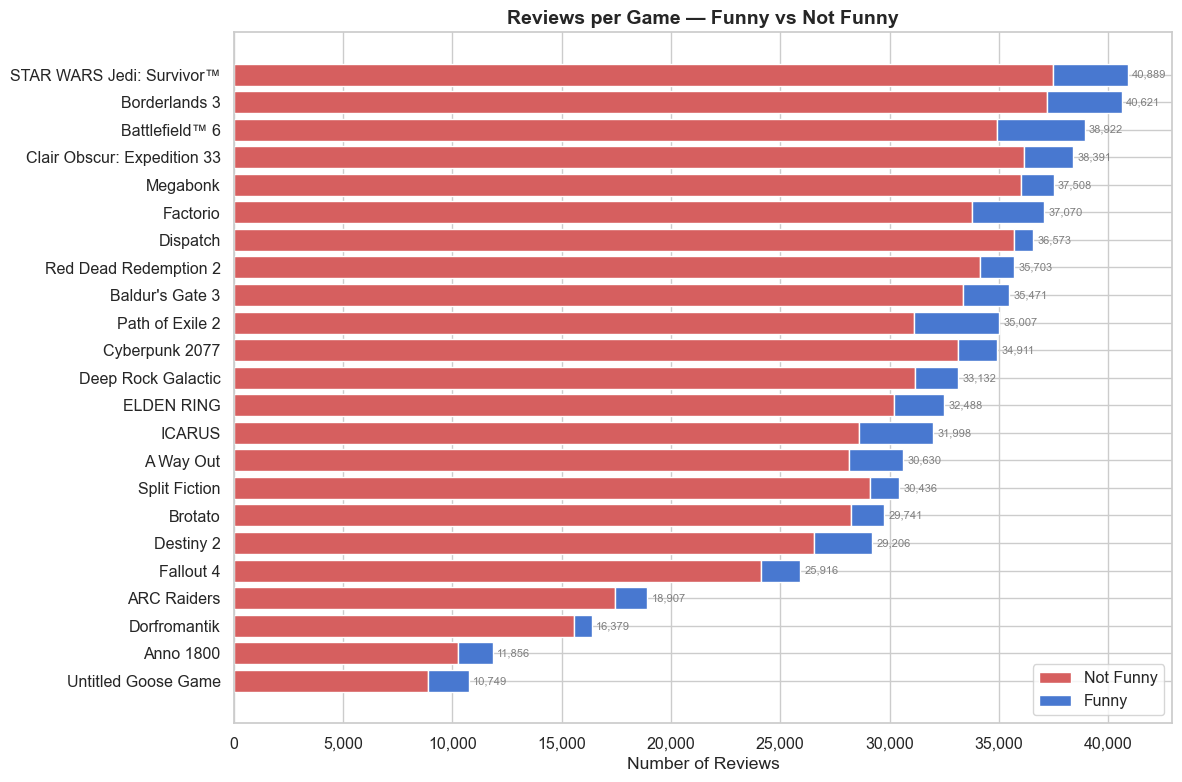

In [3]:
# --- Reviews per game: funny vs not funny (stacked) with total annotation ---
game_stats = df.groupby("app_name").agg(
    total=("review_id", "count"),
    funny=("label_is_funny_binary", "sum"),
).assign(not_funny=lambda x: x["total"] - x["funny"]).sort_values("total", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars_nf = ax.barh(game_stats.index, game_stats["not_funny"], label="Not Funny", color=sns.color_palette()[3])
bars_f  = ax.barh(game_stats.index, game_stats["funny"], left=game_stats["not_funny"], label="Funny", color=sns.color_palette()[0])

for i, (_, row) in enumerate(game_stats.iterrows()):
    ax.text(row["total"] + 200, i, f'{row["total"]:,}', va="center", fontsize=8, color="grey")

ax.set_xlabel("Number of Reviews")
ax.set_title("Reviews per Game — Funny vs Not Funny", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 2 · Funny-Vote Ratio per Game

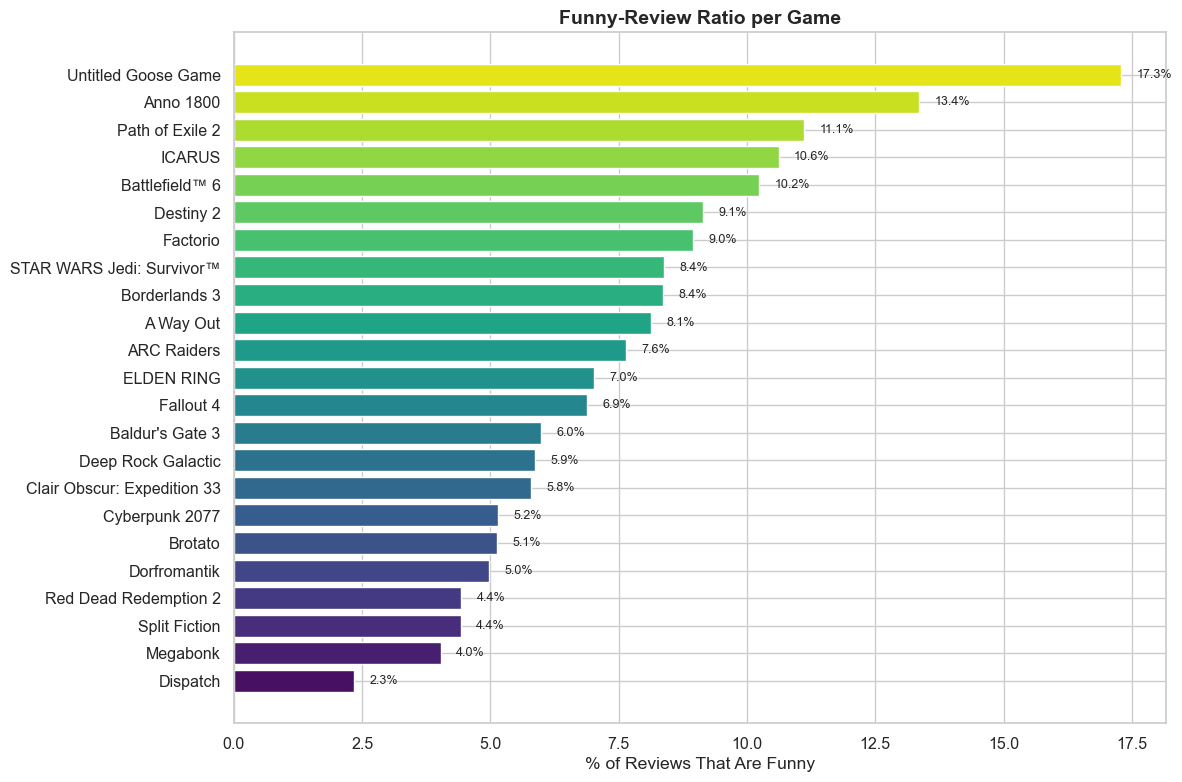

In [4]:
# --- Percentage of funny reviews per game ---
ratio = (game_stats["funny"] / game_stats["total"] * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(ratio.index, ratio.values, color=sns.color_palette("viridis", len(ratio)))
for bar, val in zip(bars, ratio.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% of Reviews That Are Funny")
ax.set_title("Funny-Review Ratio per Game", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3 · Reviews Over Time (Funny vs Not Funny)

Each subplot shows a game's weekly review count for the **last 365 days**, split by humor.

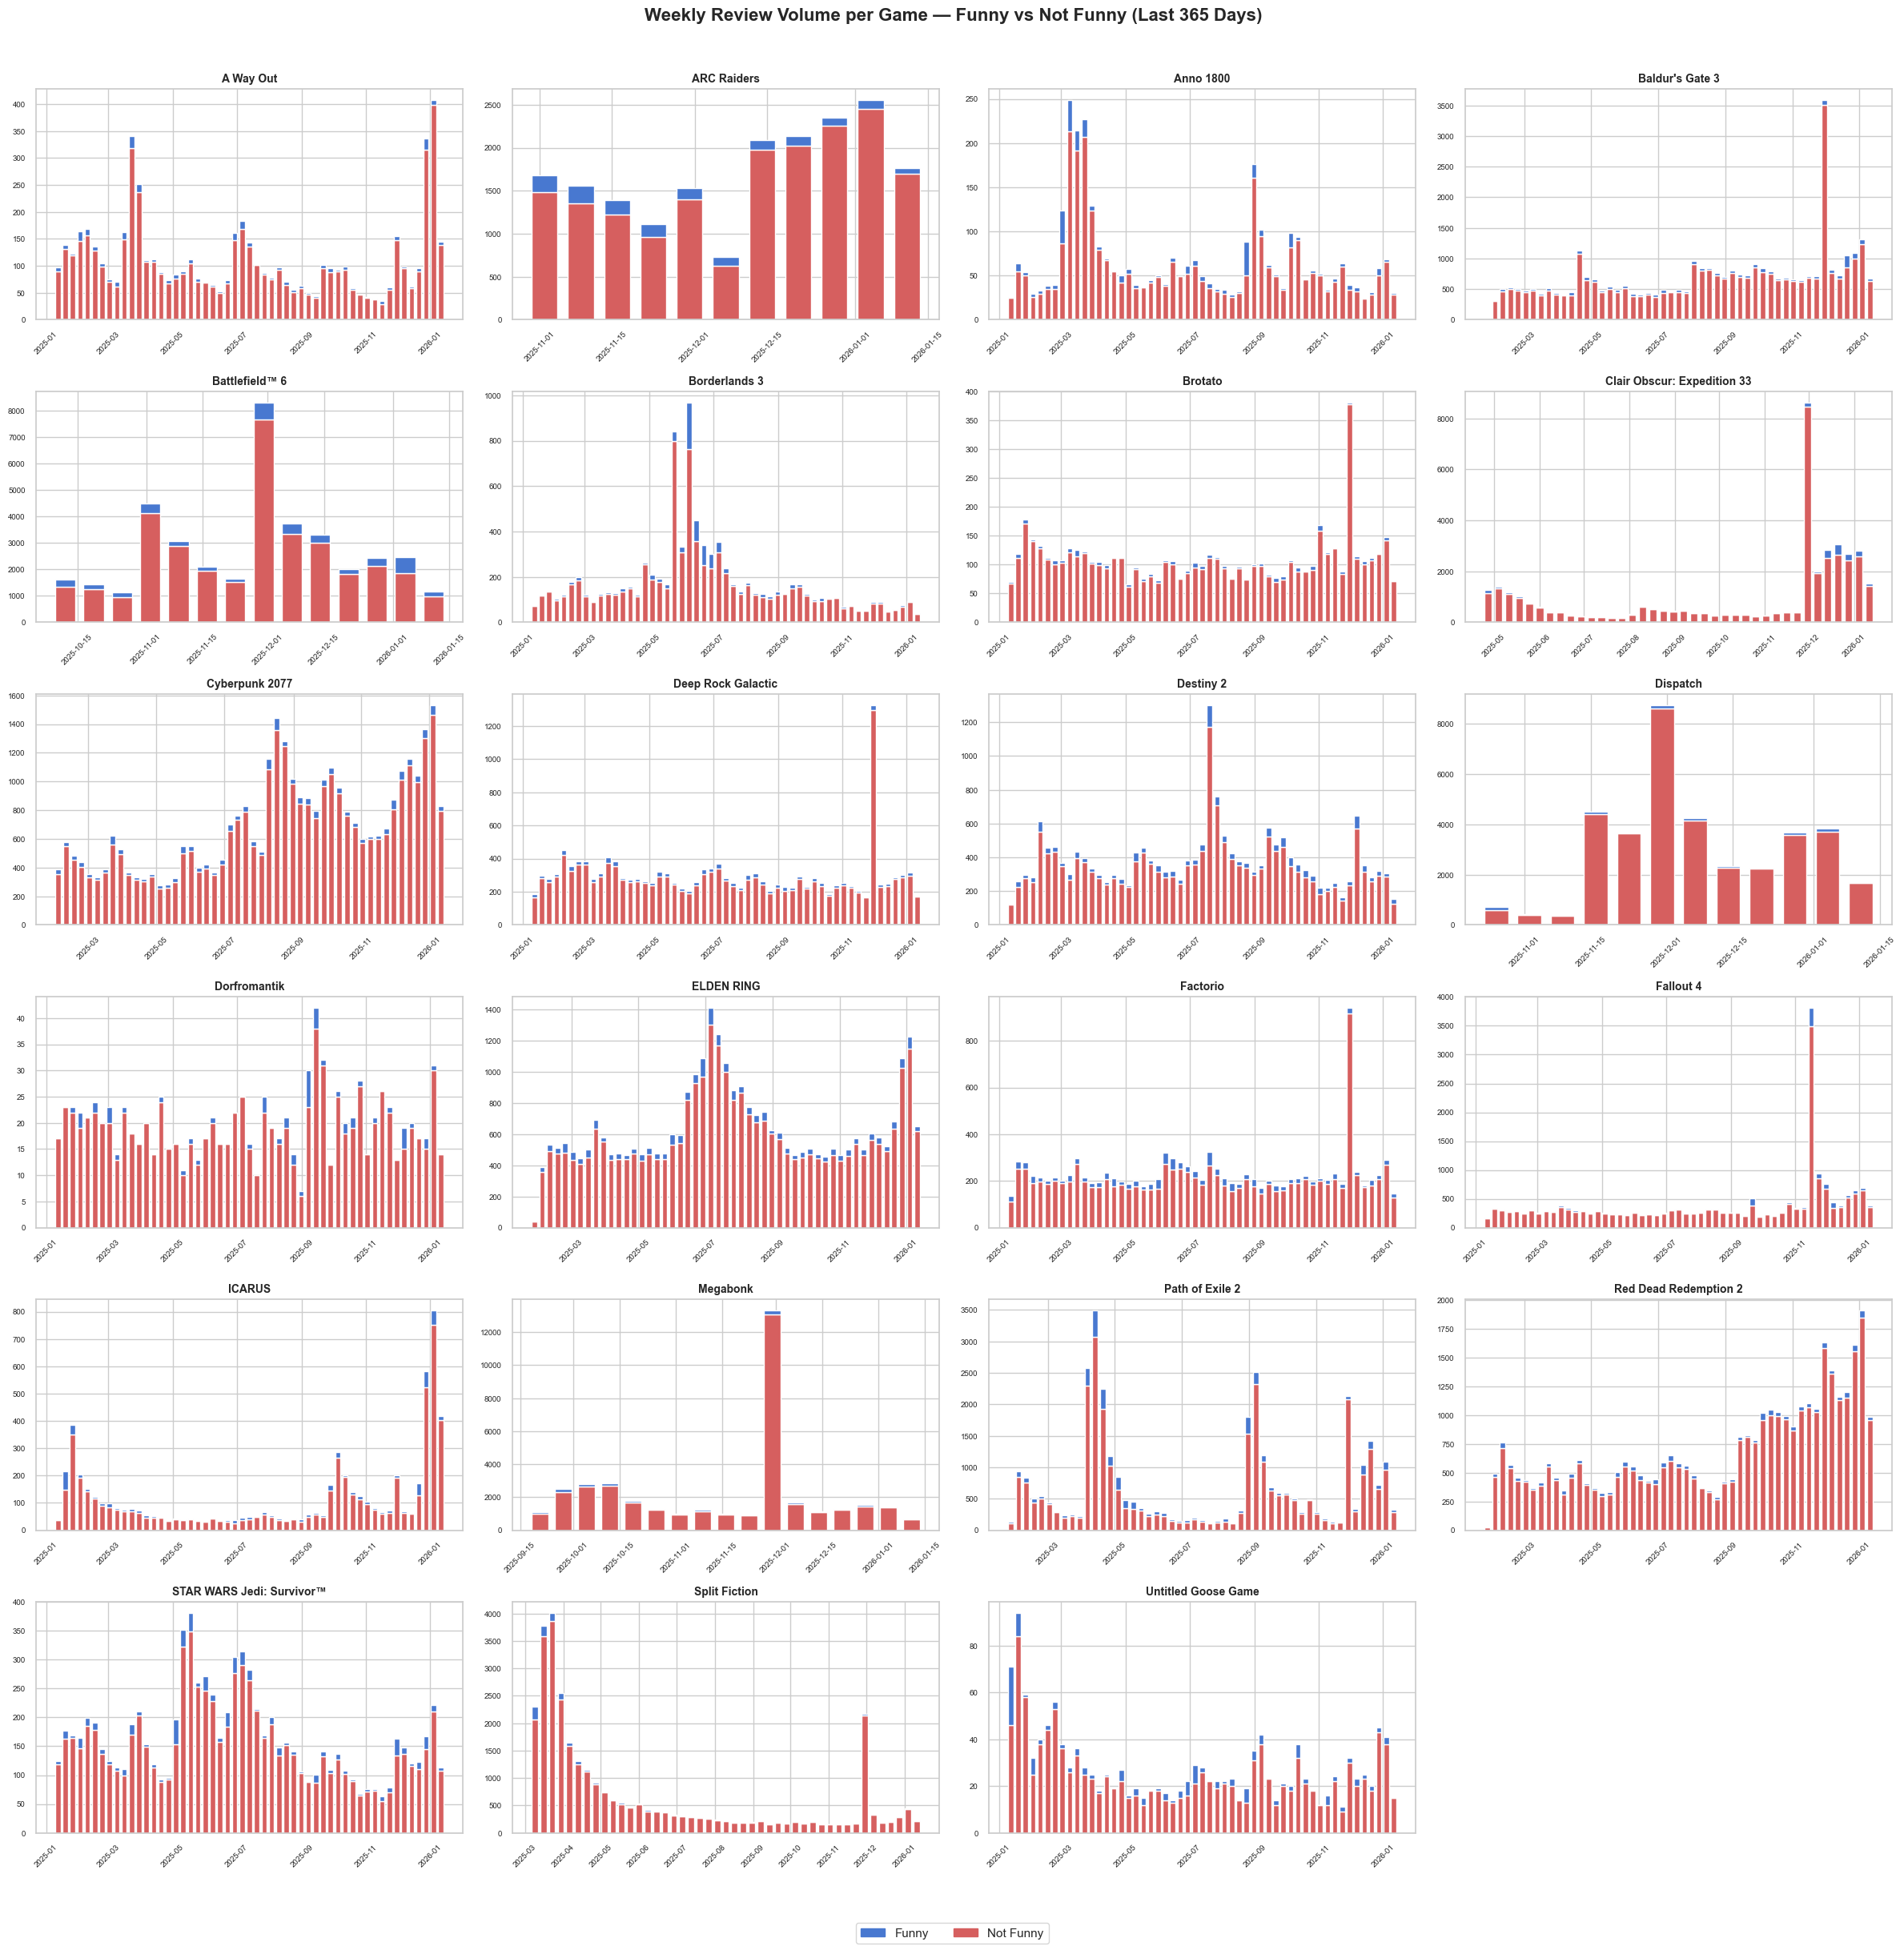

In [5]:
# --- Daily reviews since release, colour-coded by humor ---
df["days_since_release"] = (df["review_timestamp_created"] - df["app_release_date"]).dt.days

# Create a humor category column
df["review_category"] = pd.Categorical(
    df["label_is_funny_binary"].map({1: "Funny", 0: "Not Funny"}),
    categories=["Not Funny", "Funny"],
    ordered=True,
)

games_sorted = sorted(df["app_name"].unique())
n_games = len(games_sorted)
ncols = 4
nrows = int(np.ceil(n_games / ncols))

color_map = {
    "Funny": sns.color_palette()[0],      # Blue
    "Not Funny": sns.color_palette()[3],  # Red
}

fig, axes = plt.subplots(nrows, ncols, figsize=(24, nrows * 4), sharex=False, sharey=False)
axes = axes.flatten()

for idx, game in enumerate(games_sorted):
    ax = axes[idx]
    gdf = df[df["app_name"] == game]
    # Filter to last 365 days of reviews for better readability
    cutoff_date = df["review_timestamp_created"].max() - pd.Timedelta(days=365)
    gdf = gdf[gdf["review_timestamp_created"] >= cutoff_date]
    # Bin into weekly buckets for readability
    weekly = (
        gdf.groupby([pd.Grouper(key="review_timestamp_created", freq="W-SUN"), "review_category"], observed=False)
        .size()
        .unstack(fill_value=0)
    )
    # Stack bars
    bottom = np.zeros(len(weekly))
    for cat in ["Not Funny", "Funny"]:
        if cat in weekly.columns:
            ax.bar(weekly.index, weekly[cat], bottom=bottom, width=5, color=color_map[cat], label=cat)
            bottom += weekly[cat].values
    ax.set_title(game, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7, rotation=45)
    ax.tick_params(axis="y", labelsize=7)

# Hide unused axes
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

# Shared legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[c]) for c in color_map]
fig.legend(handles, color_map.keys(), loc="lower center", ncol=2, fontsize=11, frameon=True)
fig.suptitle("Weekly Review Volume per Game — Funny vs Not Funny (Last 365 Days)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.06)
plt.show()

## 4 · Funny Reviews by Label Categories

Distribution of the `votes_funny_categorical` label (0–4) across the whole dataset.

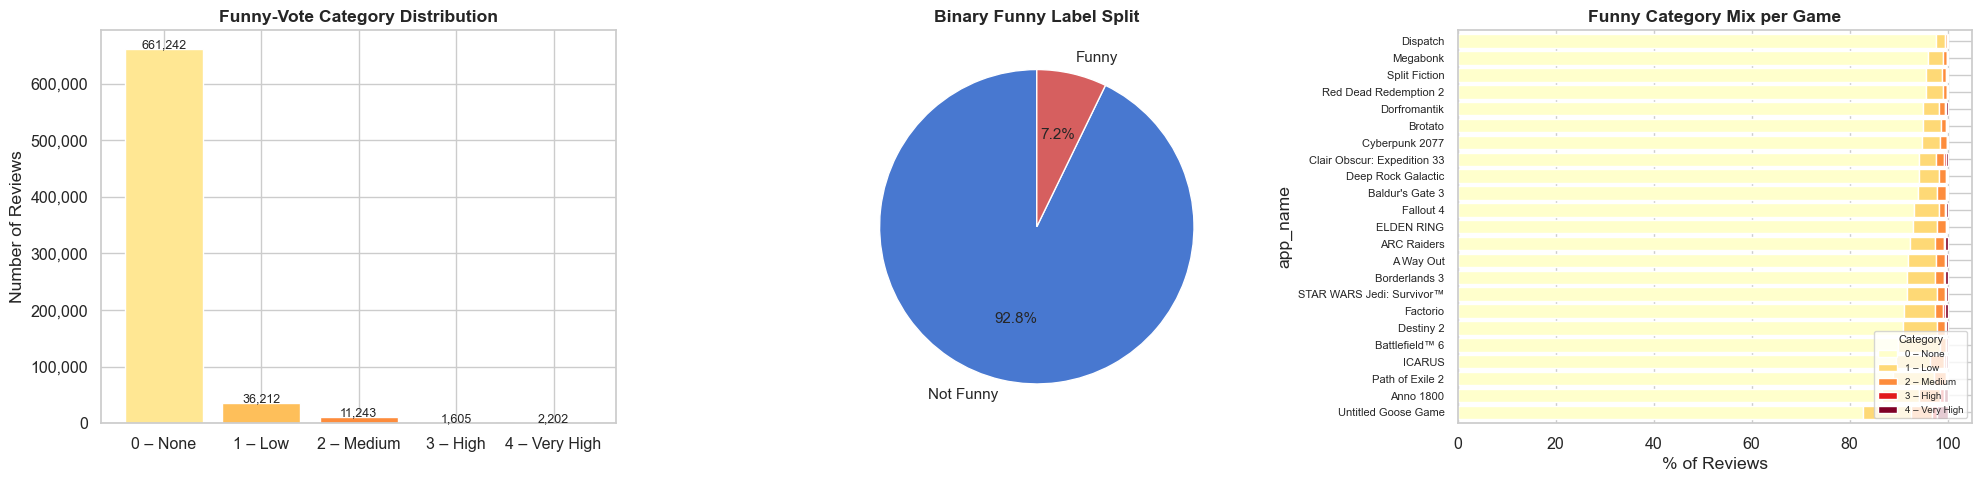

In [6]:
# --- Funny label category distributions ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 4a – Overall votes_funny_categorical distribution
cat_counts = df["votes_funny_categorical"].value_counts().sort_index()
cat_labels = {0: "0 – None", 1: "1 – Low", 2: "2 – Medium", 3: "3 – High", 4: "4 – Very High"}
ax = axes[0]
bars = ax.bar([cat_labels[c] for c in cat_counts.index], cat_counts.values, color=sns.color_palette("YlOrRd", len(cat_counts)))
for b, v in zip(bars, cat_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1000, f"{v:,}", ha="center", fontsize=9)
ax.set_title("Funny-Vote Category Distribution", fontweight="bold")
ax.set_ylabel("Number of Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 4b – Binary funny label
ax = axes[1]
binary = df["label_is_funny_binary"].value_counts().sort_index()
wedges, texts, autotexts = ax.pie(
    binary.values, labels=["Not Funny", "Funny"], autopct="%1.1f%%",
    colors=[sns.color_palette()[0], sns.color_palette()[3]], startangle=90,
    textprops={"fontsize": 11},
)
ax.set_title("Binary Funny Label Split", fontweight="bold")

# 4c – Funny category breakdown per game (stacked %)
ax = axes[2]
ct = pd.crosstab(df["app_name"], df["votes_funny_categorical"], normalize="index") * 100
ct = ct.sort_values(0, ascending=True)
ct.columns = [cat_labels[c] for c in ct.columns]
ct.plot.barh(stacked=True, ax=ax, colormap="YlOrRd", width=0.8)
ax.set_xlabel("% of Reviews")
ax.set_title("Funny Category Mix per Game", fontweight="bold")
ax.legend(title="Category", fontsize=7, title_fontsize=8, loc="lower right")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

## 5 · Mean Values & Summary Statistics per Game

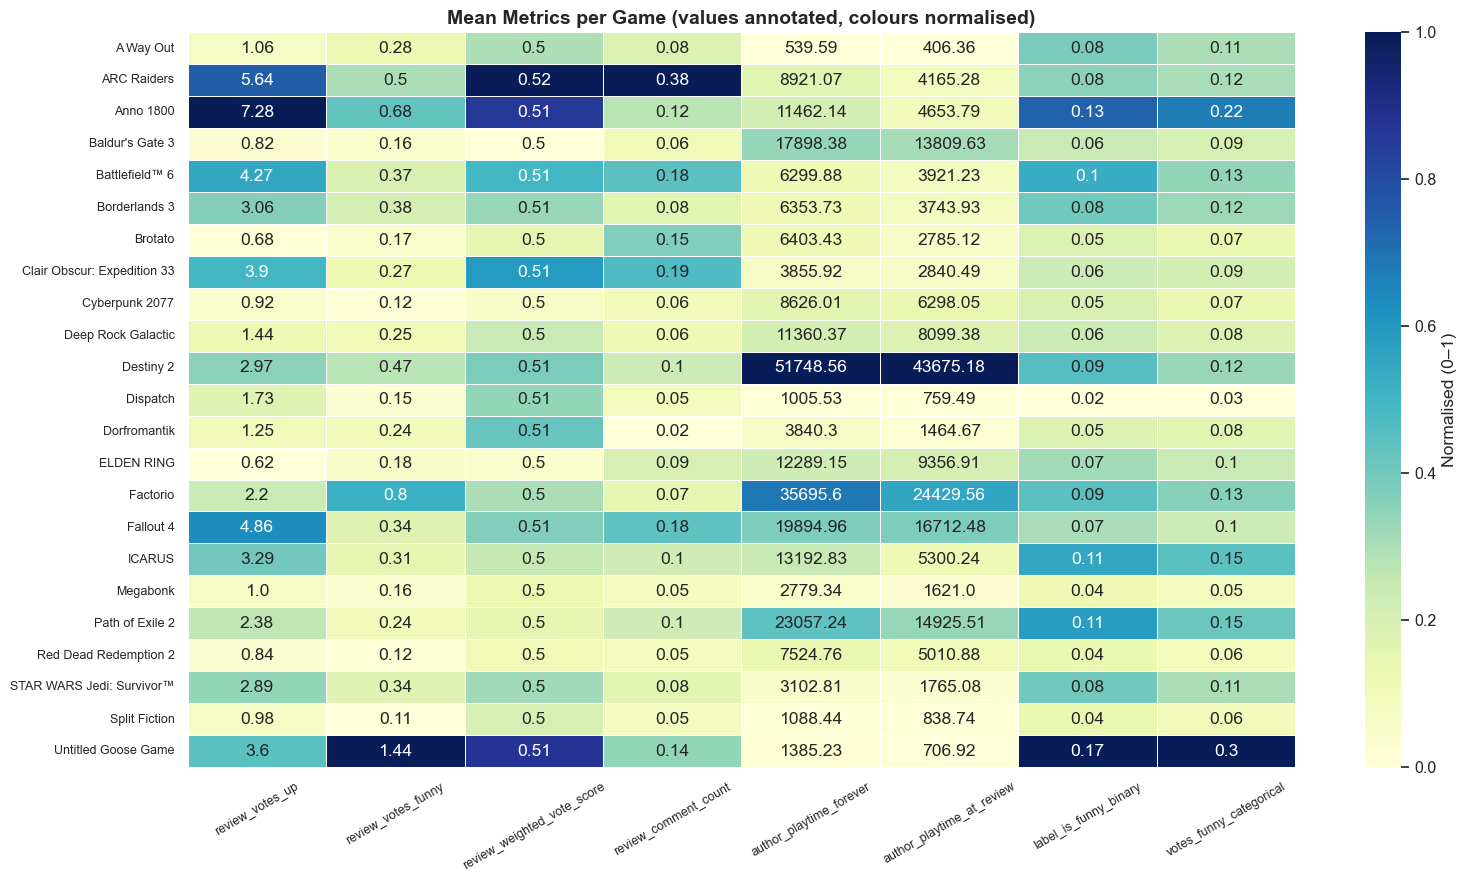

In [7]:
# --- Mean metrics per game (heatmap) ---
mean_cols = [
    "review_votes_up", "review_votes_funny", "review_weighted_vote_score",
    "review_comment_count", "author_playtime_forever", "author_playtime_at_review",
    "label_is_funny_binary", "votes_funny_categorical", 
]
game_means = df.groupby("app_name")[mean_cols].mean()

# Normalise each column to 0-1 for the heatmap colours
game_means_norm = (game_means - game_means.min()) / (game_means.max() - game_means.min())

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(
    game_means_norm.sort_index(),
    annot=game_means.sort_index().round(2).values,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Normalised (0–1)"},
)
ax.set_title("Mean Metrics per Game (values annotated, colours normalised)", fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

## 6 · Distribution of Funny Votes (log scale) & Playtime Comparison

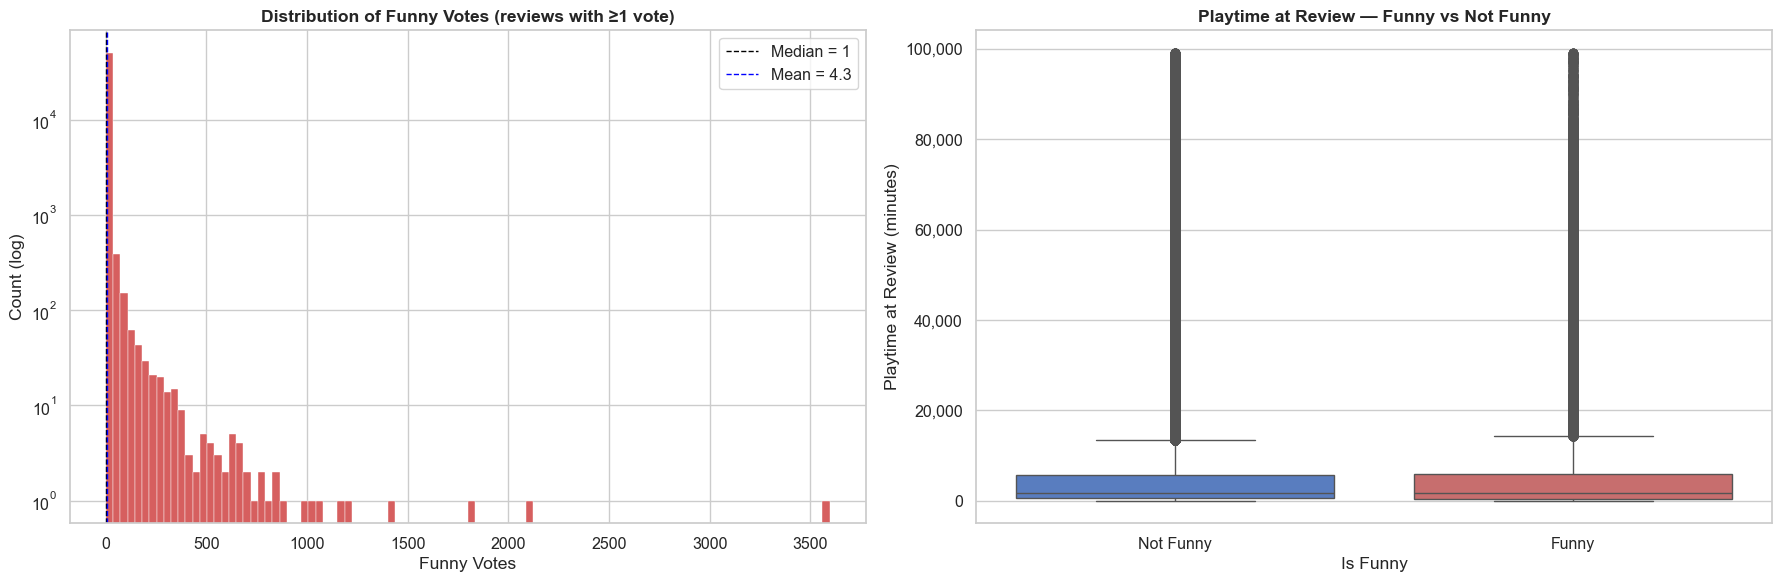

In [8]:
# --- Distributions: funny votes histogram & playtime box plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 6a – Histogram of funny votes (only reviews with ≥1 funny vote, log scale y)
funny_only = df[df["review_votes_funny"] > 0]["review_votes_funny"]
ax = axes[0]
ax.hist(funny_only, bins=100, color=sns.color_palette()[3], edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("Funny Votes")
ax.set_ylabel("Count (log)")
ax.set_title("Distribution of Funny Votes (reviews with ≥1 vote)", fontweight="bold")
ax.axvline(funny_only.median(), color="black", ls="--", lw=1, label=f"Median = {funny_only.median():.0f}")
ax.axvline(funny_only.mean(), color="blue", ls="--", lw=1, label=f"Mean = {funny_only.mean():.1f}")
ax.legend()

# 6b – Playtime at review: funny vs not funny (box plot, capped at 99th percentile)
ax = axes[1]
cap = df["author_playtime_at_review"].quantile(0.99)
plot_df = df[df["author_playtime_at_review"] <= cap].copy()
plot_df["Is Funny"] = plot_df["label_is_funny_binary"].map({0: "Not Funny", 1: "Funny"})
sns.boxplot(data=plot_df, x="Is Funny", y="author_playtime_at_review", hue="Is Funny", ax=ax, palette=[sns.color_palette()[0], sns.color_palette()[3]], legend=False)
ax.set_ylabel("Playtime at Review (minutes)")
ax.set_title("Playtime at Review — Funny vs Not Funny", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 7 · Sentiment vs Humor Crosstab & Review Length

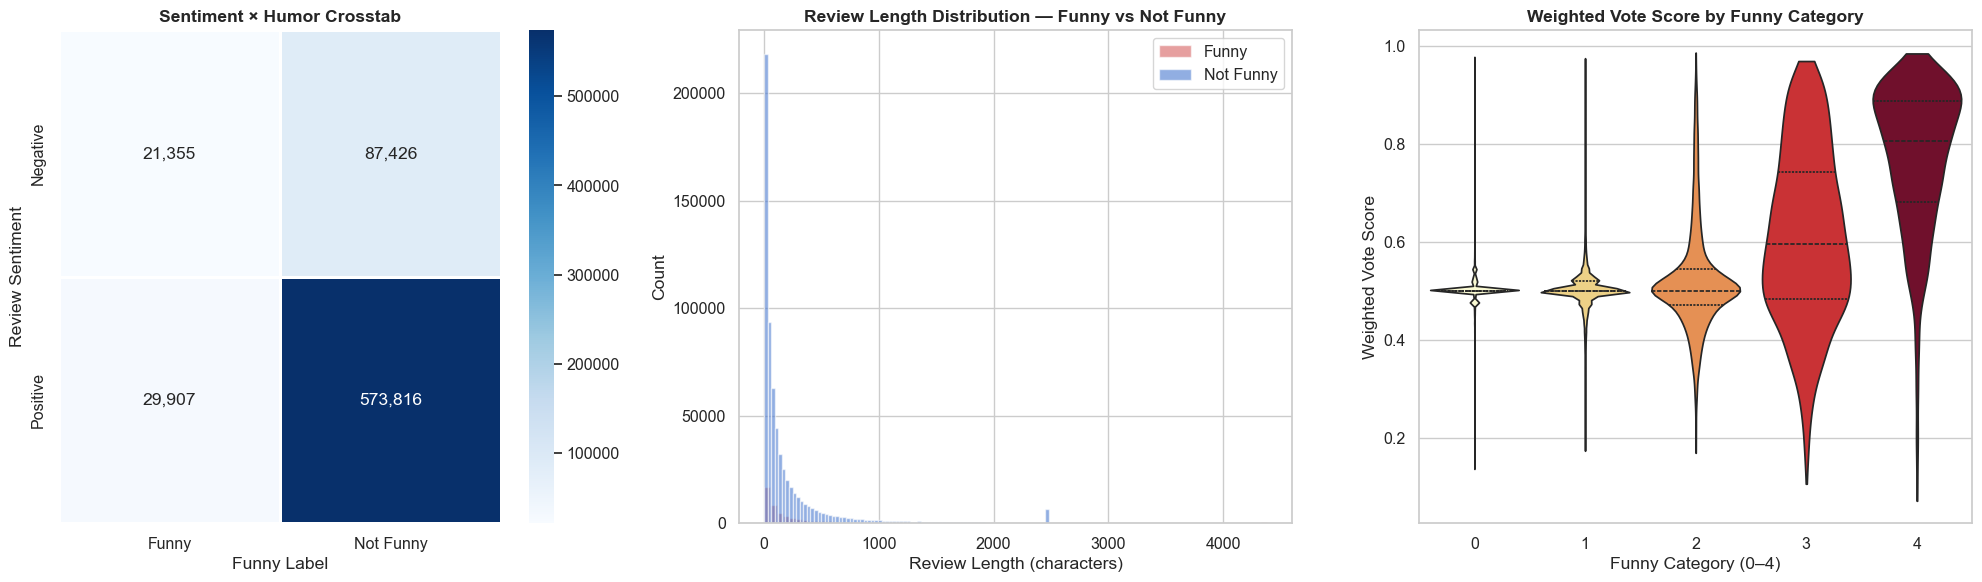

In [9]:
# --- Sentiment × Humor crosstab & review length distributions ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 7a – Confusion-matrix-style heatmap: sentiment vs funny
ct = pd.crosstab(
    df["review_voted_up"].map({True: "Positive", False: "Negative"}),
    df["label_is_funny_binary"].map({0: "Not Funny", 1: "Funny"}),
)
ax = axes[0]
sns.heatmap(ct, annot=True, fmt=",", cmap="Blues", ax=ax, linewidths=1)
ax.set_title("Sentiment × Humor Crosstab", fontweight="bold")
ax.set_ylabel("Review Sentiment")
ax.set_xlabel("Funny Label")

# 7b – Review text length distribution: funny vs not funny
df["review_length"] = df["review_text_cleaned"].str.len()
ax = axes[1]
for label, name, color in [(1, "Funny", sns.color_palette()[3]), (0, "Not Funny", sns.color_palette()[0])]:
    subset = df[df["label_is_funny_binary"] == label]["review_length"]
    ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=80, alpha=0.6, label=name, color=color)
ax.set_xlabel("Review Length (characters)")
ax.set_ylabel("Count")
ax.set_title("Review Length Distribution — Funny vs Not Funny", fontweight="bold")
ax.legend()

# 7c – Violin plot: weighted vote score by funny category
ax = axes[2]
sns.violinplot(
    data=df, x="votes_funny_categorical", y="review_weighted_vote_score",
    hue="votes_funny_categorical", ax=ax, palette="YlOrRd", inner="quartile", cut=0, legend=False,
)
ax.set_xlabel("Funny Category (0–4)")
ax.set_ylabel("Weighted Vote Score")
ax.set_title("Weighted Vote Score by Funny Category", fontweight="bold")

plt.tight_layout()
plt.show()

## 8 · Correlation Matrix & Top Funny Reviews

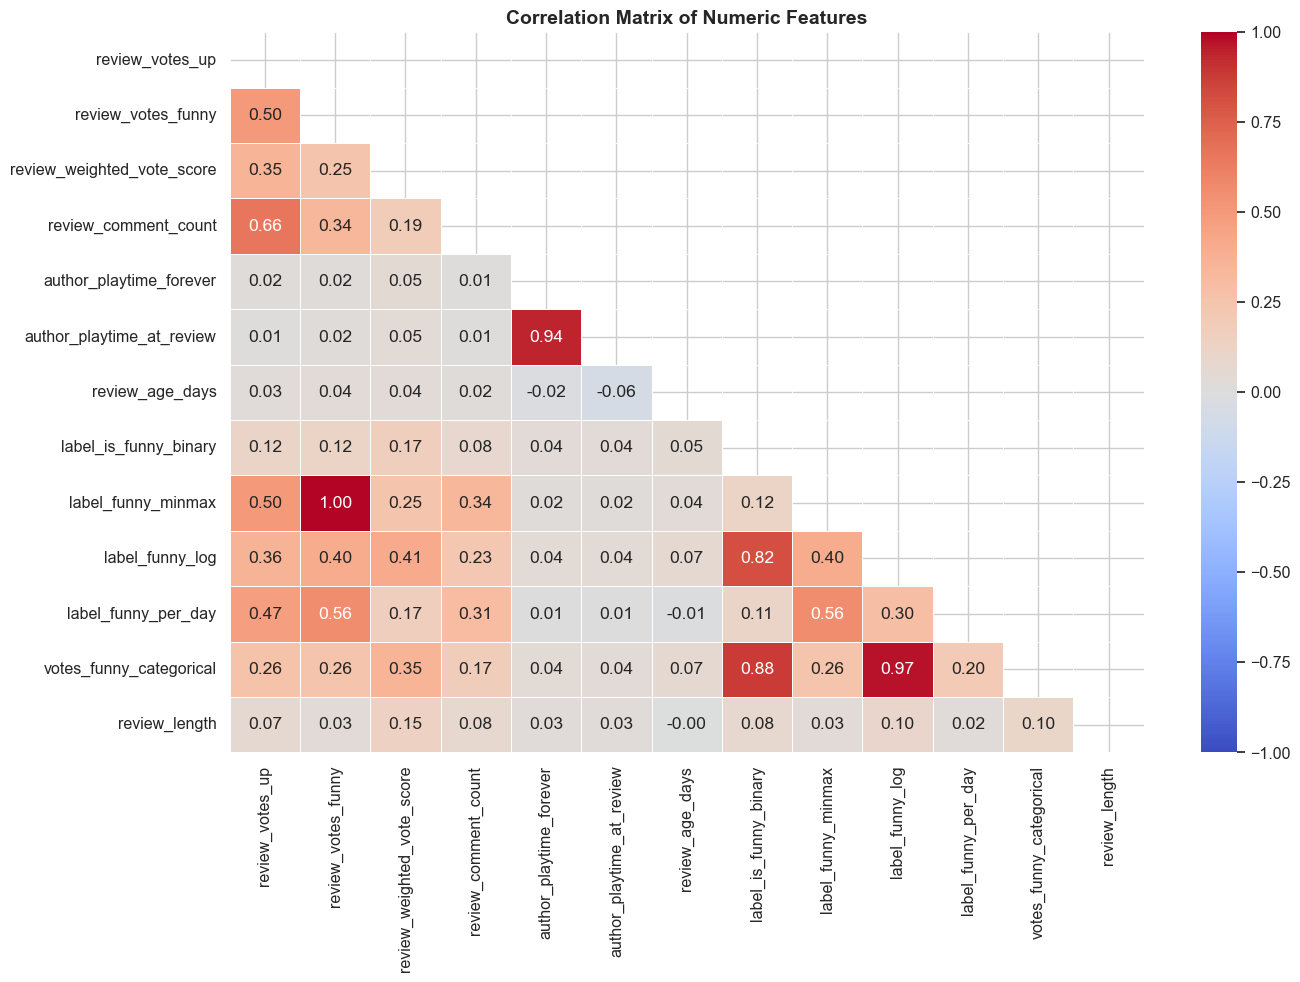

In [10]:
# --- Correlation heatmap of numeric columns ---
numeric_cols = [
    "review_votes_up", "review_votes_funny", "review_weighted_vote_score",
    "review_comment_count", "author_playtime_forever", "author_playtime_at_review",
    "review_age_days", "label_is_funny_binary", "label_funny_minmax",
    "label_funny_log", "label_funny_per_day", "votes_funny_categorical", "review_length",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9 · Steam Purchase vs Non-Purchase & Positive Rate by Humor

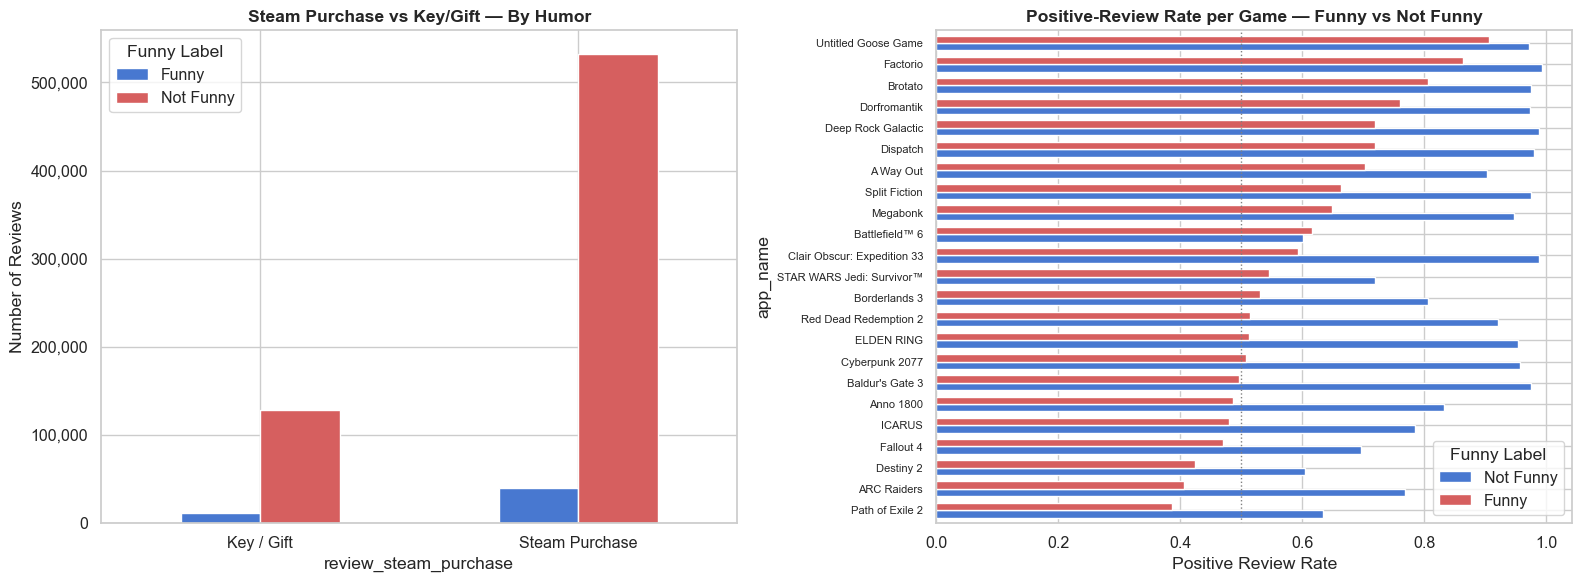

In [11]:
# --- Steam purchase split & positive-review rate by humor ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 9a – Steam purchase vs key/gift, split by funny
ax = axes[0]
ct_purchase = pd.crosstab(
    df["review_steam_purchase"].map({True: "Steam Purchase", False: "Key / Gift"}),
    df["label_is_funny_binary"].map({0: "Not Funny", 1: "Funny"}),
)
ct_purchase.plot.bar(ax=ax, color=[sns.color_palette()[0], sns.color_palette()[3]], rot=0)
ax.set_title("Steam Purchase vs Key/Gift — By Humor", fontweight="bold")
ax.set_ylabel("Number of Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title="Funny Label")

# 9b – Positive-review rate per game, funny vs not funny
ax = axes[1]
pos_rate = df.groupby(["app_name", "label_is_funny_binary"])["review_voted_up"].mean().unstack()
pos_rate.columns = ["Not Funny", "Funny"]
pos_rate = pos_rate.sort_values("Funny", ascending=True)
pos_rate.plot.barh(ax=ax, color=[sns.color_palette()[0], sns.color_palette()[3]], width=0.7)
ax.set_xlabel("Positive Review Rate")
ax.set_title("Positive-Review Rate per Game — Funny vs Not Funny", fontweight="bold")
ax.legend(title="Funny Label")
ax.tick_params(axis="y", labelsize=8)
ax.axvline(0.5, color="grey", ls=":", lw=1)

plt.tight_layout()
plt.show()

## 10 · Summary Statistics Table

In [12]:
# --- Comprehensive summary statistics per game ---
summary = df.groupby("app_name").agg(
    total_reviews=("review_id", "count"),
    pct_positive=("review_voted_up", "mean"),
    pct_funny=("label_is_funny_binary", "mean"),
    mean_funny_votes=("review_votes_funny", "mean"),
    median_funny_votes=("review_votes_funny", "median"),
    mean_upvotes=("review_votes_up", "mean"),
    mean_playtime_hrs=("author_playtime_at_review", lambda x: x.mean() / 60),
    mean_review_length=("review_length", "mean"),
    mean_weighted_score=("review_weighted_vote_score", "mean"),
    pct_steam_purchase=("review_steam_purchase", "mean"),
).round(3)

summary["pct_positive"] = (summary["pct_positive"] * 100).round(1)
summary["pct_funny"] = (summary["pct_funny"] * 100).round(1)
summary["pct_steam_purchase"] = (summary["pct_steam_purchase"] * 100).round(1)
summary = summary.sort_values("total_reviews", ascending=False)

summary.style.format({
    "total_reviews": "{:,.0f}",
    "pct_positive": "{:.1f}%",
    "pct_funny": "{:.1f}%",
    "mean_funny_votes": "{:.2f}",
    "median_funny_votes": "{:.0f}",
    "mean_upvotes": "{:.2f}",
    "mean_playtime_hrs": "{:.1f}",
    "mean_review_length": "{:.0f}",
    "mean_weighted_score": "{:.4f}",
    "pct_steam_purchase": "{:.1f}%",
}).background_gradient(cmap="YlGnBu", subset=["pct_funny", "mean_funny_votes"])

,total_reviews,pct_positive,pct_funny,mean_funny_votes,median_funny_votes,mean_upvotes,mean_playtime_hrs,mean_review_length,mean_weighted_score,pct_steam_purchase
app_name,,,,,,,,,,
STAR WARS Jedi: Survivor™,"40,889",70.5%,8.4%,0.34,0,2.89,29.4,328,0.5050,93.2%
Borderlands 3,"40,621",78.4%,8.4%,0.38,0,3.06,62.4,211,0.5050,77.3%
Battlefield™ 6,"38,922",60.3%,10.2%,0.37,0,4.27,65.4,351,0.5080,79.9%
Clair Obscur: Expedition 33,"38,391",96.5%,5.8%,0.28,0,3.90,47.3,382,0.5090,71.3%
Megabonk,"37,508",93.6%,4.0%,0.15,0,1.00,27.0,139,0.5020,94.4%
Factorio,"37,070",98.2%,9.0%,0.80,0,2.20,407.2,135,0.5050,81.7%
Dispatch,"36,573",97.5%,2.3%,0.15,0,1.74,12.7,280,0.5050,94.1%
Red Dead Redemption 2,"35,703",90.3%,4.4%,0.12,0,0.84,83.5,187,0.5020,94.5%
Baldur's Gate 3,"35,471",94.6%,6.0%,0.16,0,0.82,230.2,225,0.5000,87.5%


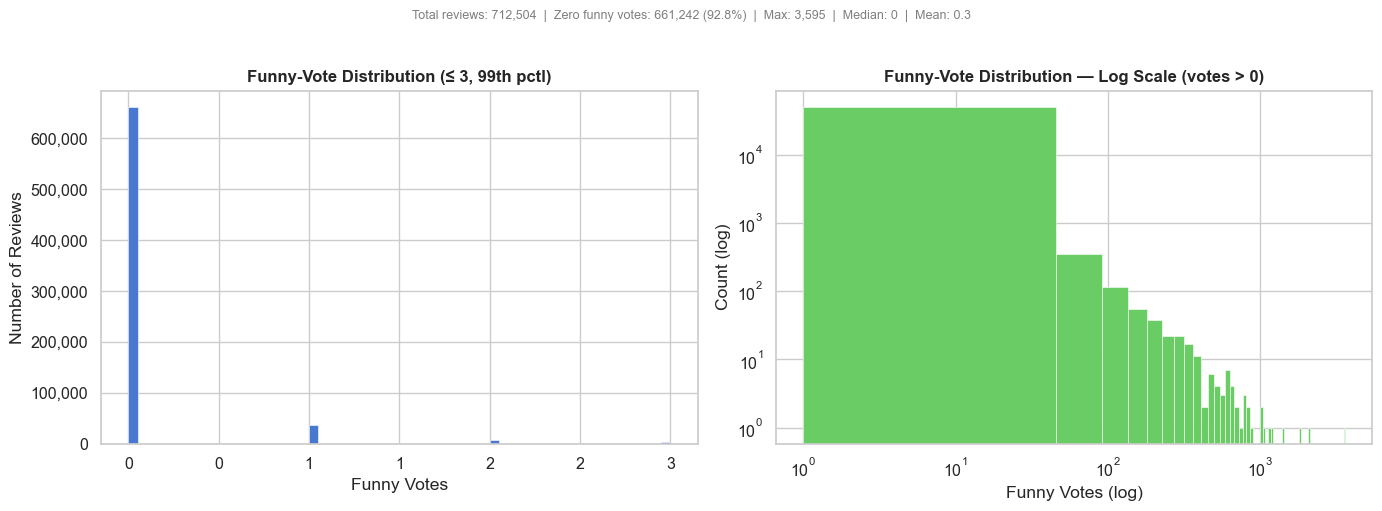

In [ ]:
votes = df["review_votes_funny"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw distribution (capped at 99th percentile for readability)
cap = int(votes.quantile(0.99))
axes[0].hist(votes[votes <= cap], bins=60, color=sns.color_palette()[0], edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Funny Votes")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title(f"Funny-Vote Distribution (≤ {cap}, 99th pctl)", fontsize=12, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: log-scaled distribution (all data)
axes[1].hist(votes[votes > 0], bins=80, color=sns.color_palette()[2], edgecolor="white", linewidth=0.4)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Funny Votes (log)")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Funny-Vote Distribution — Log Scale (votes > 0)", fontsize=12, fontweight="bold")

fig.suptitle(
    f"Total reviews: {len(votes):,}  |  Zero funny votes: {(votes == 0).sum():,} ({(votes == 0).mean():.1%})  |  "
    f"Max: {votes.max():,}  |  Median: {votes.median():.0f}  |  Mean: {votes.mean():.1f}",
    fontsize=9, y=1.02, color="grey",
)
plt.tight_layout()
plt.show()

## Distribution of Funny Votes (reviews with > 0 votes)

In [14]:
# Count of reviews grouped by votes_funny value (excluding 0)
funny = df.loc[df["review_votes_funny"] > 0, "review_votes_funny"]
vote_counts = funny.value_counts().sort_index()

summary_df = vote_counts.reset_index()
summary_df.columns = ["funny_votes", "num_reviews"]
summary_df["pct_of_total"] = (summary_df["num_reviews"] / len(df) * 100).round(2)
summary_df["pct_of_funny"] = (summary_df["num_reviews"] / len(funny) * 100).round(2)

print(f"Total reviews: {len(df):,}")
print(f"Reviews with > 0 funny votes: {len(funny):,} ({len(funny)/len(df)*100:.1f}%)")
print(f"Unique funny-vote values: {len(vote_counts)}")
print(f"Min: {funny.min()}  |  Median: {funny.median():.0f}  |  Mean: {funny.mean():.1f}  |  Max: {funny.max():,}")
print()

summary_df.style.format({
    "funny_votes": "{:,}",
    "num_reviews": "{:,}",
    "pct_of_total": "{:.2f}%",
    "pct_of_funny": "{:.2f}%",
}).hide(axis="index")

Total reviews: 712,504
Reviews with > 0 funny votes: 51,262 (7.2%)
Unique funny-vote values: 294
Min: 1  |  Median: 1  |  Mean: 4.3  |  Max: 3,595



funny_votes,num_reviews,pct_of_total,pct_of_funny
1,"36,212",5.08%,70.64%
2,"6,790",0.95%,13.25%
3,"2,464",0.35%,4.81%
4,"1,235",0.17%,2.41%
5,754,0.11%,1.47%
6,516,0.07%,1.01%
7,385,0.05%,0.75%
8,289,0.04%,0.56%
9,224,0.03%,0.44%
10,191,0.03%,0.37%


## Label Distribution Summary

Review counts and percentages for each labelling strategy used in the dataset.

In [15]:
from IPython.display import display, HTML

def label_table(series, title, group_labels=None):
    """Build a styled frequency table for a label column."""
    counts = series.value_counts().sort_index()
    tbl = counts.reset_index()
    tbl.columns = ["value", "num_reviews"]
    if group_labels:
        tbl["label"] = tbl["value"].map(group_labels)
    else:
        tbl["label"] = tbl["value"]
    tbl["pct"] = (tbl["num_reviews"] / tbl["num_reviews"].sum() * 100)
    tbl = tbl[["label", "num_reviews", "pct"]]
    styled = tbl.style.format({
        "num_reviews": "{:,.0f}",
        "pct": "{:.2f}%",
    }).hide(axis="index").set_caption(title).set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left"), ("padding-bottom", "6px")]},
    ]).background_gradient(cmap="YlOrRd", subset=["pct"])
    return styled

# --- 1. Binary label ---
binary_labels = {0: "Not Funny", 1: "Funny"}
s1 = label_table(df["label_is_funny_binary"], "label_is_funny_binary (threshold: votes_funny > 0)", binary_labels)

# --- 2. Categorical label ---
cat_labels = {0: "0 – None (0 votes)", 1: "1 – Low (1 vote)", 2: "2 – Medium (2–5 votes)", 3: "3 – High (6–10 votes)", 4: "4 – Very High (>10 votes)"}
s2 = label_table(df["votes_funny_categorical"], "votes_funny_categorical", cat_labels)

# --- 3. Log label (grouped to integer floor) ---
log_bins = np.floor(df["label_funny_log"]).astype(int)
log_counts = log_bins.value_counts().sort_index()
log_tbl = log_counts.reset_index()
log_tbl.columns = ["log_floor", "num_reviews"]
log_tbl["approx_votes_range"] = log_tbl["log_floor"].apply(
    lambda x: f"{int(np.expm1(x)):,}–{int(np.expm1(x + 1)) - 1:,}" if x > 0 else "0"
)
log_tbl["label"] = log_tbl.apply(lambda r: f"{r['log_floor']}  (≈ {r['approx_votes_range']} votes)", axis=1)
log_tbl["pct"] = log_tbl["num_reviews"] / log_tbl["num_reviews"].sum() * 100
log_styled = log_tbl[["label", "num_reviews", "pct"]].style.format({
    "num_reviews": "{:,.0f}",
    "pct": "{:.2f}%",
}).hide(axis="index").set_caption("label_funny_log (grouped by ⌊log1p(votes)⌋)").set_table_styles([
    {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px"), ("text-align", "left"), ("padding-bottom", "6px")]},
]).background_gradient(cmap="YlOrRd", subset=["pct"])

# --- 4. MinMax label (binned into 10 buckets) ---
minmax_bins = pd.cut(df["label_funny_minmax"], bins=10, include_lowest=True)
s4 = label_table(minmax_bins, "label_funny_minmax (binned into 10 equal-width ranges)")

# --- 5. Per-day velocity (binned) ---
perday_bins = pd.cut(
    df["label_funny_per_day"],
    bins=[-0.001, 0, 0.01, 0.1, 0.5, 1, df["label_funny_per_day"].max() + 1],
    labels=["0 (no votes)", "0–0.01", "0.01–0.1", "0.1–0.5", "0.5–1", ">1"],
)
s5 = label_table(perday_bins, "label_funny_per_day (velocity: votes_funny / review_age_days)")

# Display all tables
for s in [s1, s2, log_styled, s4, s5]:
    display(s)
    display(HTML("<br>"))

label,num_reviews,pct
Not Funny,"661,242",92.81%
Funny,"51,262",7.19%


label,num_reviews,pct
0 – None (0 votes),"661,242",92.81%
1 – Low (1 vote),"36,212",5.08%
2 – Medium (2–5 votes),"11,243",1.58%
3 – High (6–10 votes),"1,605",0.23%
4 – Very High (>10 votes),"2,202",0.31%


label,num_reviews,pct
0 (≈ 0 votes),"697,454",97.89%
1 (≈ 1–5 votes),"11,759",1.65%
2 (≈ 6–18 votes),"1,950",0.27%
3 (≈ 19–52 votes),768,0.11%
4 (≈ 53–146 votes),383,0.05%
5 (≈ 147–401 votes),146,0.02%
"6 (≈ 402–1,094 votes)",38,0.01%
"7 (≈ 1,095–2,978 votes)",5,0.00%
"8 (≈ 2,979–8,101 votes)",1,0.00%


label,num_reviews,pct
"(-0.002, 0.1]","712,448",99.99%
"(0.1, 0.2]",40,0.01%
"(0.2, 0.3]",10,0.00%
"(0.3, 0.4]",3,0.00%
"(0.4, 0.5]",0,0.00%
"(0.5, 0.6]",2,0.00%
"(0.6, 0.7]",0,0.00%
"(0.7, 0.8]",0,0.00%
"(0.8, 0.9]",0,0.00%
"(0.9, 1.0]",1,0.00%


label,num_reviews,pct
0 (no votes),"661,242",92.81%
0–0.01,"33,916",4.76%
0.01–0.1,"16,165",2.27%
0.1–0.5,977,0.14%
0.5–1,104,0.01%
>1,100,0.01%


## 11 · Review Text Length Analysis

Distribution of review text lengths (in characters) across the dataset, broken down by game and humor label.

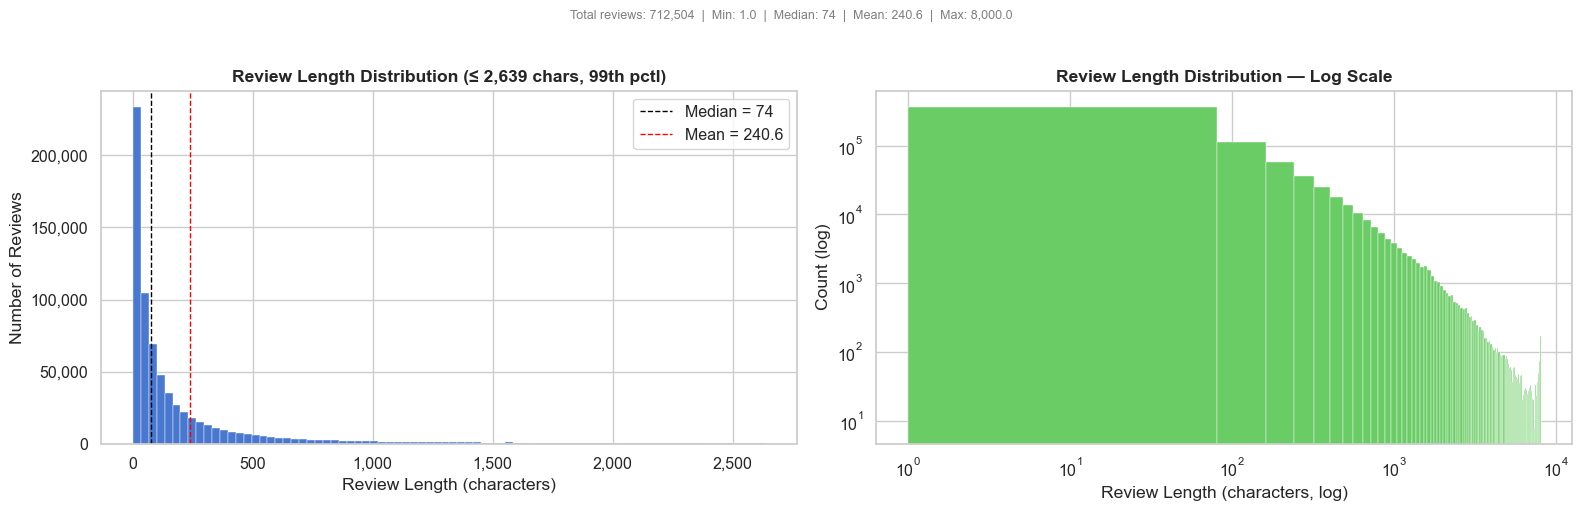

In [16]:
# --- 11a: Overall review length distribution ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw distribution capped at 99th percentile
cap99 = int(df["review_length"].quantile(0.99))
axes[0].hist(df["review_length"][df["review_length"] <= cap99], bins=80,
             color=sns.color_palette()[0], edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Review Length (characters)")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title(f"Review Length Distribution (≤ {cap99:,} chars, 99th pctl)", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].axvline(df["review_length"].median(), color="black", ls="--", lw=1,
                label=f'Median = {df["review_length"].median():,.0f}')
axes[0].axvline(df["review_length"].mean(), color="red", ls="--", lw=1,
                label=f'Mean = {df["review_length"].mean():,.1f}')
axes[0].legend()

# Right: log-scaled distribution
axes[1].hist(df["review_length"][df["review_length"] > 0], bins=100,
             color=sns.color_palette()[2], edgecolor="white", linewidth=0.3)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Review Length (characters, log)")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Review Length Distribution — Log Scale", fontweight="bold")

fig.suptitle(
    f"Total reviews: {len(df):,}  |  Min: {df['review_length'].min():,}  |  "
    f"Median: {df['review_length'].median():,.0f}  |  Mean: {df['review_length'].mean():,.1f}  |  "
    f"Max: {df['review_length'].max():,}",
    fontsize=9, y=1.02, color="grey",
)
plt.tight_layout()
plt.show()

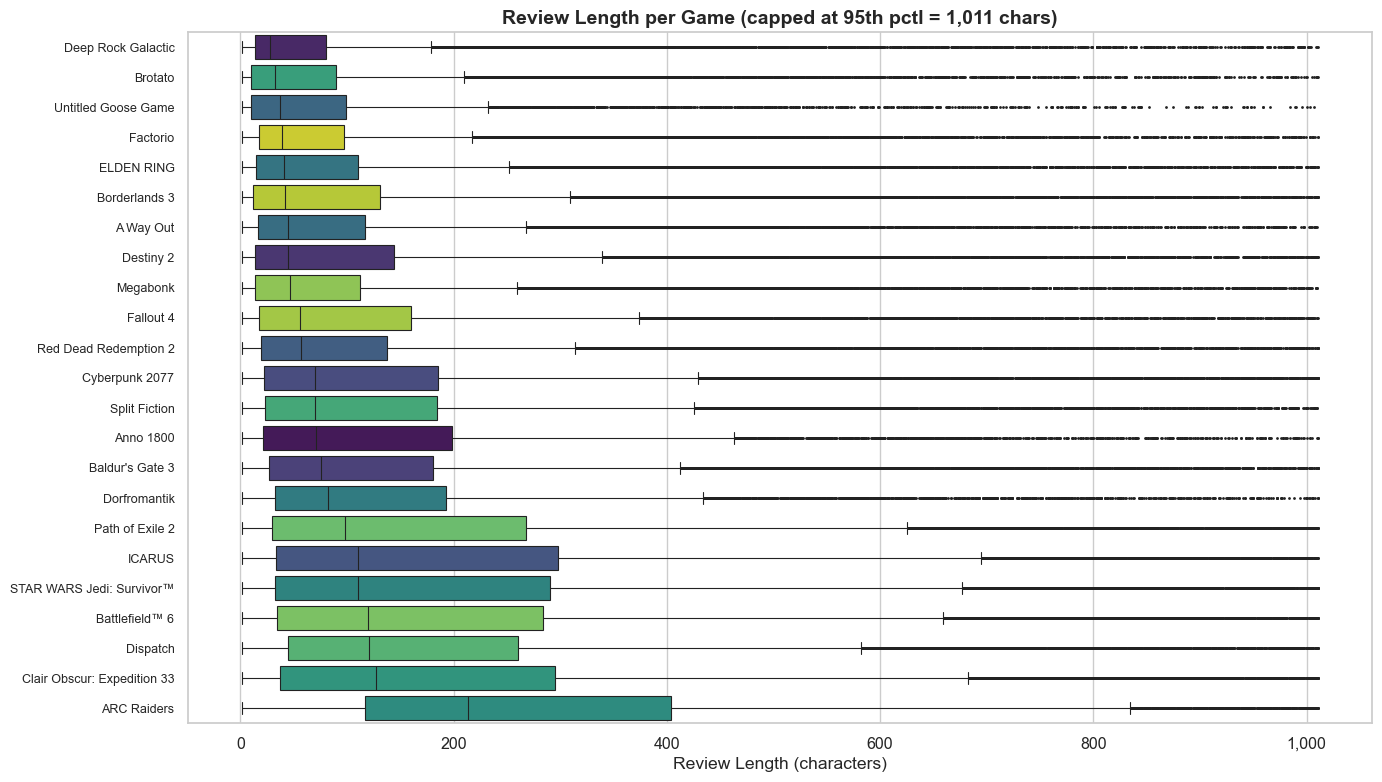

In [17]:
# --- 11b: Review length by game (box plot) ---
fig, ax = plt.subplots(figsize=(14, 8))
cap95 = int(df["review_length"].quantile(0.95))
plot_data = df[df["review_length"] <= cap95].copy()

game_order = plot_data.groupby("app_name")["review_length"].median().sort_values().index
sns.boxplot(
    data=plot_data, y="app_name", x="review_length", order=game_order,
    hue="app_name", palette="viridis", legend=False, ax=ax,
    fliersize=1, linewidth=0.8,
)
ax.set_xlabel("Review Length (characters)")
ax.set_ylabel("")
ax.set_title(f"Review Length per Game (capped at 95th pctl = {cap95:,} chars)", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

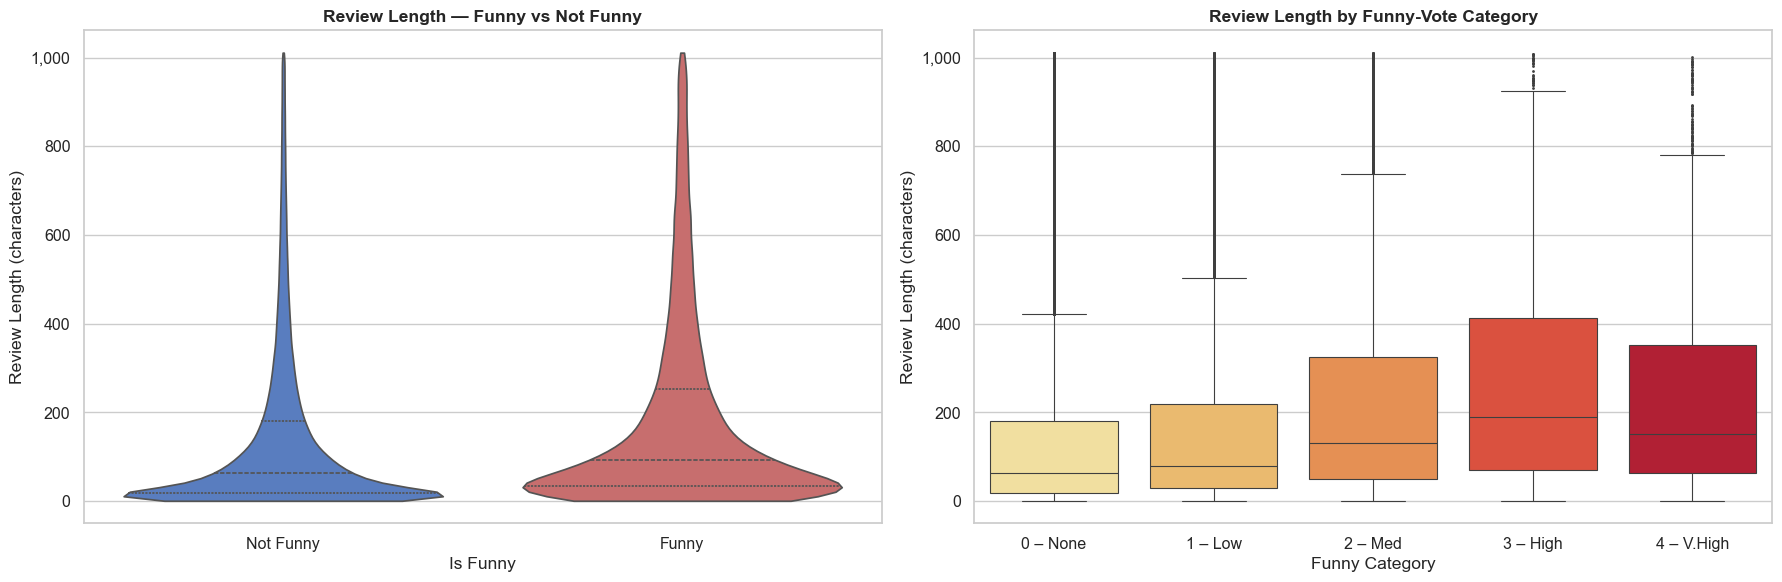

In [18]:
# --- 11c: Review length by funny category (violin + box) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: violin plot by funny binary label
cap95 = int(df["review_length"].quantile(0.95))
plot_data = df[df["review_length"] <= cap95].copy()
plot_data["Is Funny"] = plot_data["label_is_funny_binary"].map({0: "Not Funny", 1: "Funny"})

sns.violinplot(
    data=plot_data, x="Is Funny", y="review_length", hue="Is Funny",
    palette=[sns.color_palette()[0], sns.color_palette()[3]],
    inner="quartile", cut=0, ax=axes[0], legend=False,
)
axes[0].set_ylabel("Review Length (characters)")
axes[0].set_title("Review Length — Funny vs Not Funny", fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: box plot by votes_funny_categorical
cat_order = sorted(plot_data["votes_funny_categorical"].unique())
cat_labels_map = {0: "0 – None", 1: "1 – Low", 2: "2 – Med", 3: "3 – High", 4: "4 – V.High"}
plot_data["funny_cat_label"] = plot_data["votes_funny_categorical"].map(cat_labels_map)
cat_label_order = [cat_labels_map[c] for c in cat_order]
sns.boxplot(
    data=plot_data, x="funny_cat_label", y="review_length", order=cat_label_order,
    hue="funny_cat_label", palette="YlOrRd", legend=False, ax=axes[1],
    fliersize=1, linewidth=0.8,
)
axes[1].set_xlabel("Funny Category")
axes[1].set_ylabel("Review Length (characters)")
axes[1].set_title("Review Length by Funny-Vote Category", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [19]:
# --- 11d: Review length summary statistics table ---
length_stats = df.groupby("app_name")["review_length"].agg(
    count="count", mean="mean", std="std",
    min="min", median="median", max="max",
    **{f"p{p}": lambda x, p=p: x.quantile(p / 100) for p in [5, 25, 75, 95]},
).sort_values("median", ascending=False)

# Overall row
overall = df["review_length"].agg(["count", "mean", "std", "min", "median", "max"])
overall["p5"] = df["review_length"].quantile(0.05)
overall["p25"] = df["review_length"].quantile(0.25)
overall["p75"] = df["review_length"].quantile(0.75)
overall["p95"] = df["review_length"].quantile(0.95)
overall.name = "ALL GAMES"
length_stats = pd.concat([pd.DataFrame(overall).T, length_stats])

length_stats.style.format({
    "count": "{:,.0f}", "mean": "{:,.1f}", "std": "{:,.1f}",
    "min": "{:,.0f}", "median": "{:,.0f}", "max": "{:,.0f}",
    "p5": "{:,.0f}", "p25": "{:,.0f}", "p75": "{:,.0f}", "p95": "{:,.0f}",
}).set_caption("Review Length Statistics per Game (characters)").set_table_styles([
    {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px"),
                                       ("text-align", "left"), ("padding-bottom", "6px")]},
]).background_gradient(cmap="YlGnBu", subset=["mean", "median"])

,count,mean,std,min,median,max,p5,p25,p75,p95
ALL GAMES,"710,078",240.6,540.8,1,74,"8,000",4,21,222,"1,011"
ARC Raiders,"18,904",519.3,774.7,1,256,"7,978",60,128,561,"1,889"
Clair Obscur: Expedition 33,"38,331",381.8,724.2,1,149,"7,991",6,44,392,"1,526"
Battlefield™ 6,"38,837",351.1,644.3,1,139,"7,990",4,41,371,"1,415"
ICARUS,"31,852",408.9,786.7,1,138,"8,000",5,40,427,"1,689"
Dispatch,"36,498",280.4,511.6,1,131,"7,971",7,49,298,"1,016"
STAR WARS Jedi: Survivor™,"40,711",328.3,606.4,1,130,"7,991",5,37,362,"1,291"
Path of Exile 2,"34,920",331.1,631.1,1,115,"7,995",4,35,348,"1,369"
Dorfromantik,"16,328",183.1,338.4,1,86,"8,000",8,33,205,649
Baldur's Gate 3,"35,344",225.3,504.7,1,82,"7,991",5,29,208,881


## 12 · Relationship Between Funny Votes and Upvotes

Scatter plots and a hexbin density view showing how `review_votes_funny` relates to `review_votes_up`.

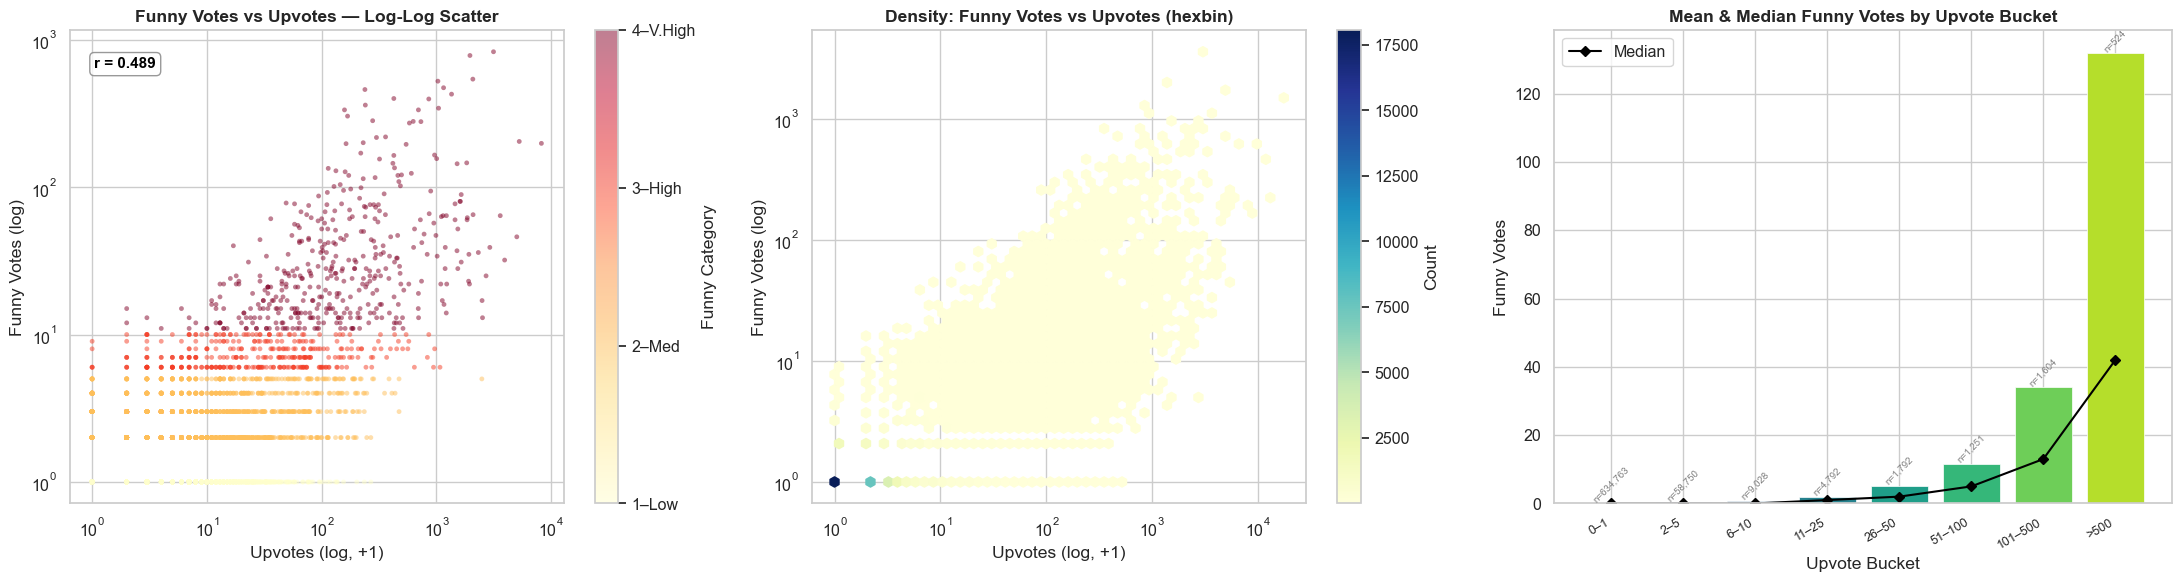

In [20]:
# --- 12: Funny votes vs Upvotes relationship ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 12a – Log-log scatter (sampled for readability) coloured by funny category
sample = df[df["review_votes_funny"] > 0].sample(n=min(10_000, len(df[df["review_votes_funny"] > 0])), random_state=42)
scatter = axes[0].scatter(
    sample["review_votes_up"] + 1,
    sample["review_votes_funny"],
    c=sample["votes_funny_categorical"],
    cmap="YlOrRd", alpha=0.5, s=12, edgecolors="none",
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Upvotes (log, +1)")
axes[0].set_ylabel("Funny Votes (log)")
axes[0].set_title("Funny Votes vs Upvotes — Log-Log Scatter", fontweight="bold")
cbar = fig.colorbar(scatter, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.set_label("Funny Category")
cbar.ax.set_yticklabels(["0–None", "1–Low", "2–Med", "3–High", "4–V.High"])

# Add correlation annotation
r = df.loc[df["review_votes_funny"] > 0, ["review_votes_up", "review_votes_funny"]].corr().iloc[0, 1]
axes[0].annotate(f"r = {r:.3f}", xy=(0.05, 0.92), xycoords="axes fraction",
                 fontsize=11, fontweight="bold", color="black",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.8))

# 12b – Hexbin density plot (all reviews with > 0 funny votes)
pos = df[df["review_votes_funny"] > 0]
hb = axes[1].hexbin(
    pos["review_votes_up"] + 1, pos["review_votes_funny"],
    gridsize=50, cmap="YlGnBu", mincnt=1,
    xscale="log", yscale="log",
)
axes[1].set_xlabel("Upvotes (log, +1)")
axes[1].set_ylabel("Funny Votes (log)")
axes[1].set_title("Density: Funny Votes vs Upvotes (hexbin)", fontweight="bold")
fig.colorbar(hb, ax=axes[1], label="Count")

# 12c – Mean funny votes by upvote bucket
vote_bins = pd.cut(
    df["review_votes_up"],
    bins=[0, 1, 5, 10, 25, 50, 100, 500, df["review_votes_up"].max() + 1],
    labels=["0–1", "2–5", "6–10", "11–25", "26–50", "51–100", "101–500", ">500"],
    include_lowest=True,
)
bucket_stats = df.groupby(vote_bins, observed=False)["review_votes_funny"].agg(["mean", "median", "count"])
ax = axes[2]
x_pos = range(len(bucket_stats))
bars = ax.bar(x_pos, bucket_stats["mean"], color=sns.color_palette("viridis", len(bucket_stats)),
              edgecolor="white", linewidth=0.5)
ax.plot(x_pos, bucket_stats["median"], "D-", color="black", markersize=5, label="Median")
for i, (mean_val, count) in enumerate(zip(bucket_stats["mean"], bucket_stats["count"])):
    ax.text(i, mean_val + 0.3, f"n={count:,}", ha="center", fontsize=7, color="grey", rotation=45)
ax.set_xticks(x_pos)
ax.set_xticklabels(bucket_stats.index, rotation=30, ha="right", fontsize=9)
ax.set_xlabel("Upvote Bucket")
ax.set_ylabel("Funny Votes")
ax.set_title("Mean & Median Funny Votes by Upvote Bucket", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()